In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Found 10000 files.
GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


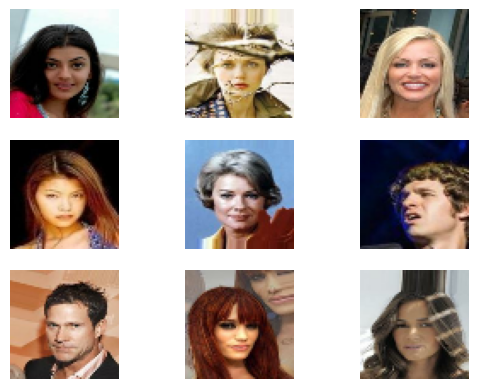

In [ ]:
from tensorflow import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

dataset = keras.utils.image_dataset_from_directory(r"/content/drive/MyDrive/celeb10k",
                                                   label_mode=None, image_size=(64, 64),
                                                   batch_size=32)
dataset = dataset.map(lambda x: x/255)

# Check if a GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
else:
    print("GPU is NOT available. Check your runtime settings.")

images = dataset.take(9)
for i, x in enumerate(images):
    plt.subplot(3,3,i+1)
    plt.axis("off")
    plt.imshow((x.numpy() * 255).astype("int32")[0])

In [ ]:
# Discriminator
from tensorflow.keras import layers
discriminator = keras.Sequential([
    keras.Input(shape=(64, 64, 3)),
    layers.Conv2D(64, kernel_size=4, strides=2, padding="same"),
    layers.LeakyReLU(alpha=0.2),
    layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
    layers.LeakyReLU(alpha=0.2),
    layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
    layers.LeakyReLU(alpha=0.2),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")],
    name="discriminator")
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,801 (1.54 MB)

 Trainable params: 404,801 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Generator
latent_dim = 128
generator = keras.Sequential(
    [keras.Input(shape=(latent_dim,)),
    layers.Dense(8 * 8 * 128),
    layers.Reshape((8, 8, 128)),
    layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
    layers.LeakyReLU(alpha=0.2),
    layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding="same"),
    layers.LeakyReLU(alpha=0.2),
    layers.Conv2DTranspose(512, kernel_size=4, strides=2, padding="same"),
    layers.LeakyReLU(alpha=0.2),
    layers.Conv2D(3, kernel_size=5, padding="same", activation="sigmoid")],
    name="generator")
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 256)    │       524,544 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 512)    │     2,097,664 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64, 64, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 3)      │        38,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,979,651 (15.18 MB)

 Trainable params: 3,979,651 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# GAN implementation
import tensorflow as tf

class GAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    @property
    def metrics(self): # metrics for tracking two losses over each epoch
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        # draw random samples from the latent space
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim)
        )
        # decode the random points into fake images
        generated_images = self.generator(random_latent_vectors)
        # combine fake images with real images
        combined_images = tf.concat([generated_images, real_images], axis=0)
        # create the corresponding labels: 1 = fake, 0 = real
        labels = tf.concat(
            [tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))],
            axis=0
        )
        # add random noise to the label
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        # train the discriminator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )
        # draw random samples from the latent space
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim)
        )
        # create labels saying that all fake images are real
        misleading_labels = tf.zeros((batch_size, 1))

        # train the generator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(
                self.generator(random_latent_vectors)
            )
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(
            zip(grads, self.generator.trainable_weights)
        )
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result()
        }

In [ ]:
# This callback will use the generator to create fake images and save
# them at the end of each epoch
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim
    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal(
            shape=(self.num_img, self.latent_dim)
        )
        generated_images = self.model.generator(random_latent_vectors)
        generated_images *= 255
        generated_images.numpy()
        for i in range(self.num_img):
            img = keras.utils.array_to_img(generated_images[i])
            img.save(rf"/content/drive/MyDrive/GANgen/generated_img_{epoch:03d}_{i}.png")

In [ ]:
# Compiling and training GAN
epochs = 5
gan = GAN(discriminator=discriminator,
          generator=generator,
          latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy(),
    )
gan.fit(
    dataset, epochs=epochs,
    callbacks=[GANMonitor(num_img=10, latent_dim=latent_dim)]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 273ms/step - d_loss: 0.5332 - g_loss: 1.5406
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 135s 264ms/step - d_loss: 0.5448 - g_loss: 1.5259
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 273ms/step - d_loss: 0.5953 - g_loss: 1.5611
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 277ms/step - d_loss: 0.5546 - g_loss: 1.2058
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 278ms/step - d_loss: 0.6017 - g_loss: 1.1896


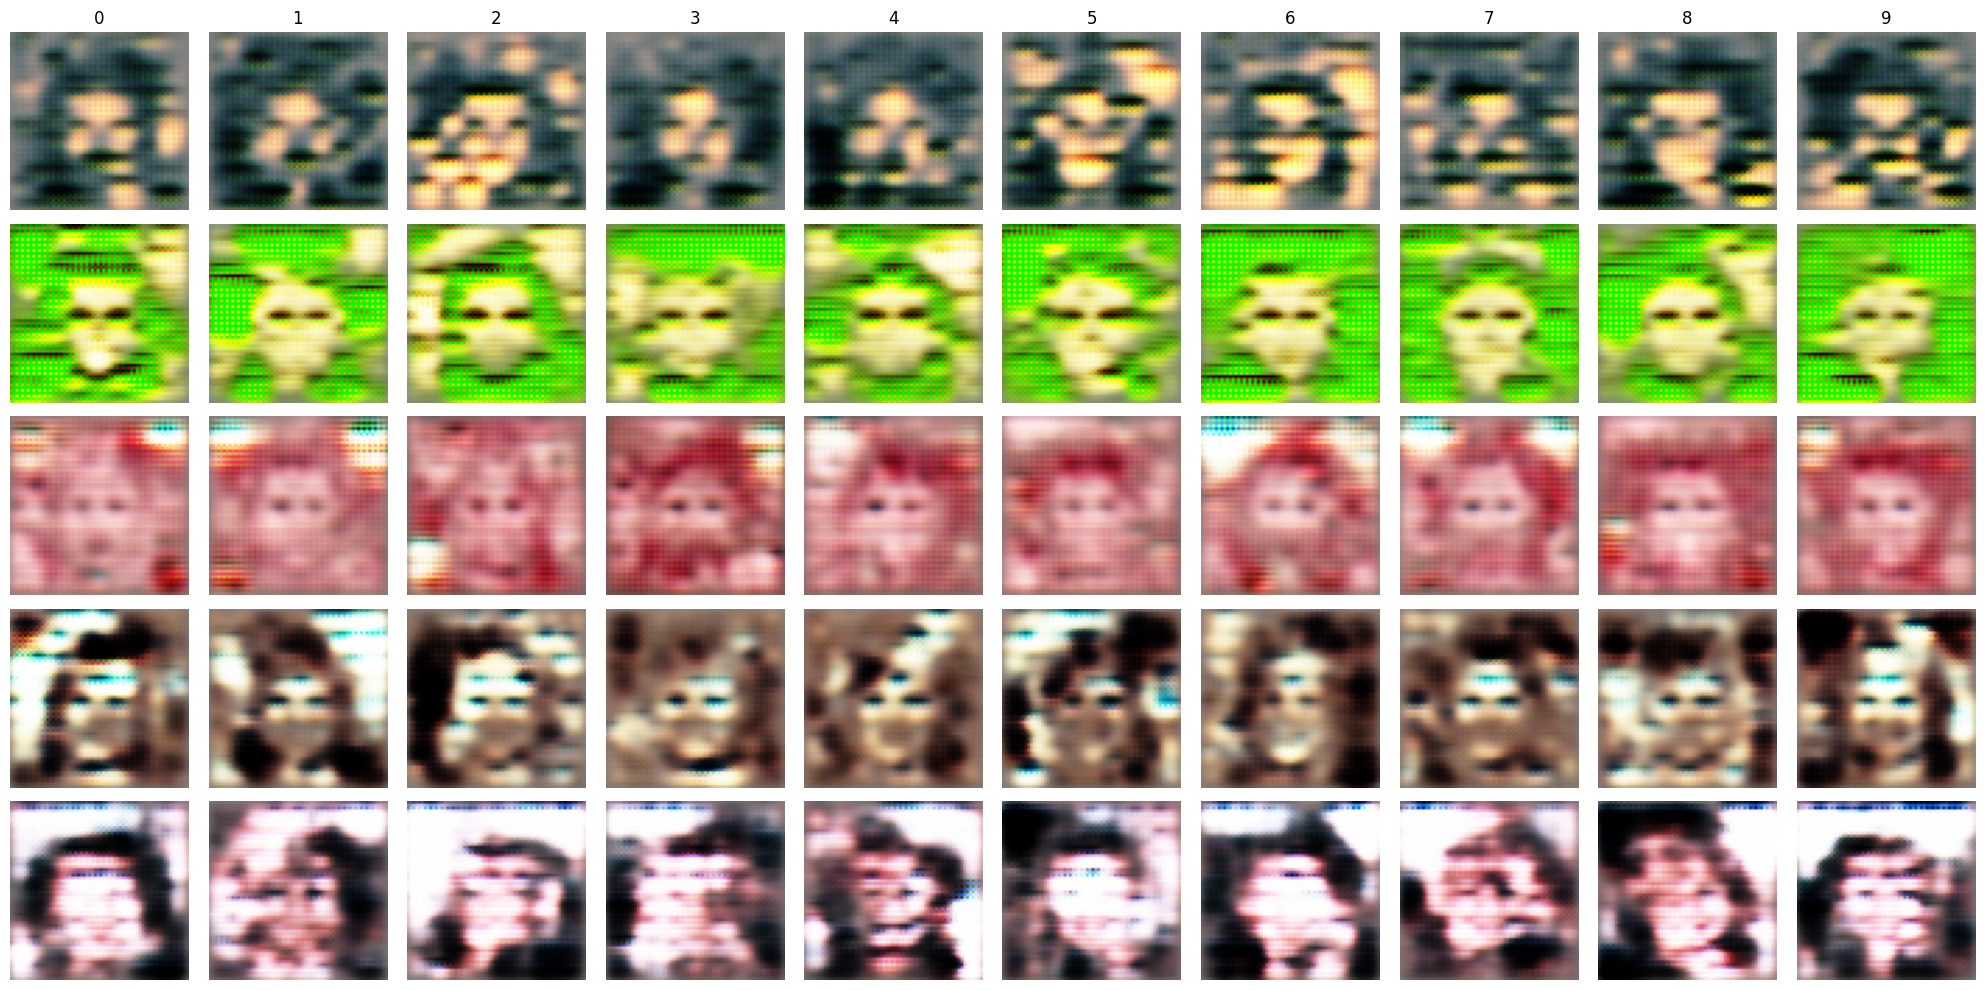

In [ ]:
# Plot your results
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

base_path = "/content/drive/MyDrive/GANgen"

epochs = range(5)   # 000–004
imgs = range(10)    # 0–9

fig, axes = plt.subplots(len(epochs), len(imgs), figsize=(20, 10))

for e_idx, epoch in enumerate(epochs):
    for i_idx, i in enumerate(imgs):
        path = f"{base_path}/generated_img_{epoch:03d}_{i}.png"

        ax = axes[e_idx, i_idx]

        if os.path.exists(path):
            img = mpimg.imread(path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "Missing", ha='center', va='center')

        ax.axis('off')

        # label axes
        if e_idx == 0:
            ax.set_title(f"{i}")
        if i_idx == 0:
            ax.set_ylabel(f"{epoch:03d}", rotation=0, labelpad=20)

plt.tight_layout()
plt.show()